# 01 — CIFAR-10 and k-Nearest Neighbors: Distances

In this notebook we move from synthetic arrays to real CIFAR-10 images and implement the first part of a k-nearest-neighbor (kNN) classifier.

## Learning objectives

- inspect a real image-classification dataset;
- create training, validation, and test subsets without mixing their roles;
- flatten images while preserving the number of examples;
- derive and implement squared Euclidean distance;
- understand the shape of a many-query/many-training distance matrix.

This notebook intentionally uses small subsets and two explicit loops. Faster distance implementations, neighbor voting, hyperparameter selection, and evaluation come next.

In [50]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

SEED = 42
rng = np.random.default_rng(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

## 1. Load CIFAR-10

The first run downloads the dataset into the ignored `data/` directory. Torchvision exposes the raw image arrays as `dataset.data` with shape `(N, 32, 32, 3)` and labels as integers from 0 through 9.

The setup cell handles both common working directories: the repository root and its `notebooks/` directory.

In [51]:
train_dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
test_dataset = CIFAR10(root=DATA_DIR, train=False, download=True)

X_train_full = train_dataset.data
y_train_full = np.asarray(train_dataset.targets)
X_test_full = test_dataset.data
y_test_full = np.asarray(test_dataset.targets)

print("training images:", X_train_full.shape, X_train_full.dtype)
print("training labels:", y_train_full.shape, y_train_full.dtype)
print("test images:", X_test_full.shape, X_test_full.dtype)
print("pixel range:", X_train_full.min(), X_train_full.max())

training images: (50000, 32, 32, 3) uint8
training labels: (50000,) int64
test images: (10000, 32, 32, 3) uint8
pixel range: 0 255


### Exercise 1 — Dataset inspection

Complete the cell below, then answer these questions in a new Markdown cell:

1. What does each axis of `X_train_full` represent?
2. How many examples belong to each class?
3. Is CIFAR-10 balanced? What evidence supports your answer?

In [52]:
X_train_full.shape

(50000, 32, 32, 3)

In [53]:
# use NumPy to count the training examples for labels 0 through 9.
class_counts = np.array([np.sum(y_train_full == i) for i in range(10)])

assert class_counts.shape == (10,)
assert class_counts.sum() == len(y_train_full)
for class_name, count in zip(CLASS_NAMES, class_counts):
    print(f"{class_name:>10}: {count}")

  airplane: 5000
automobile: 5000
      bird: 5000
       cat: 5000
      deer: 5000
       dog: 5000
      frog: 5000
     horse: 5000
      ship: 5000
     truck: 5000


1. 50000 - images, 32x32 - image size, 3 - color channels
2. 5000 examples for each class
3. dataset is balanced. evidence above

## 2. Visualize examples

Always look at the data before modeling it. CIFAR-10 images are tiny, varied, and often ambiguous—properties that will matter when comparing raw pixels.

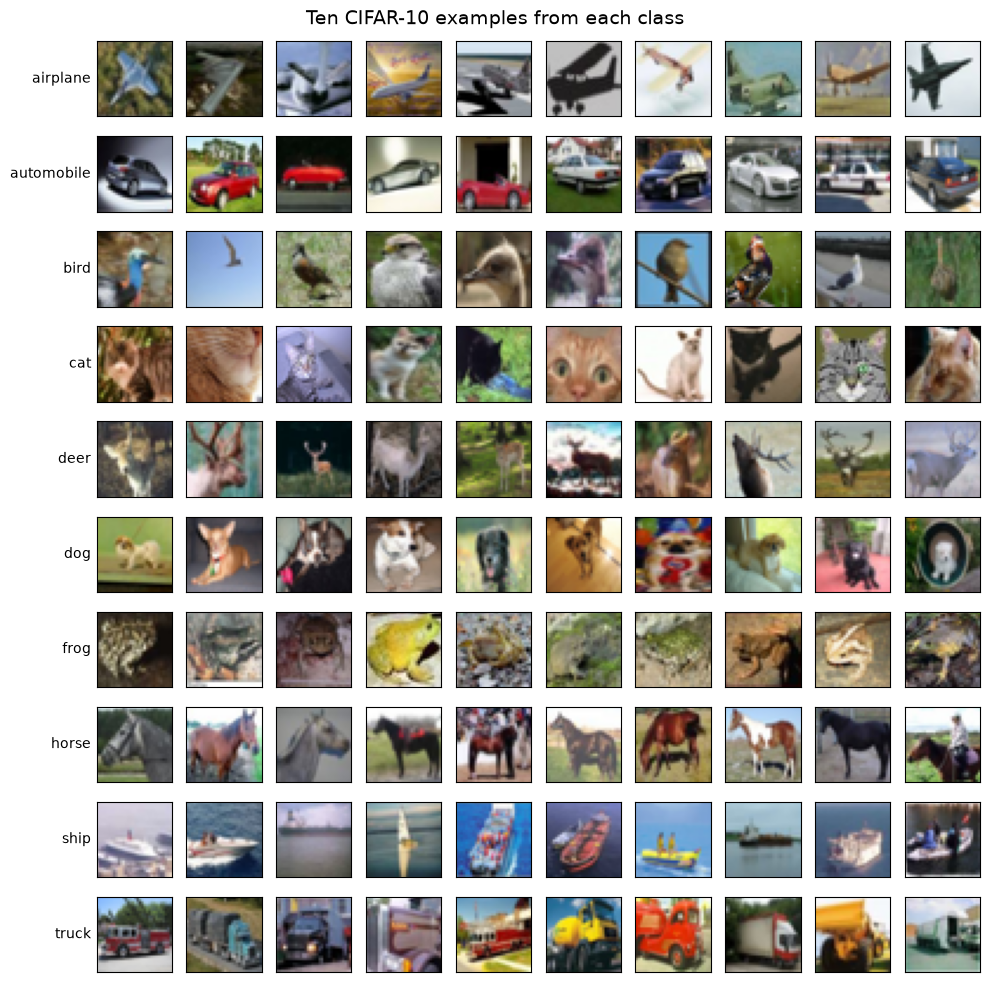

In [54]:
NUM_EXAMPLES_PER_CLASS = 10
fig, axes = plt.subplots(
    len(CLASS_NAMES),
    NUM_EXAMPLES_PER_CLASS,
    figsize=(10, 10),
)

for label, class_name in enumerate(CLASS_NAMES):
    matching_indices = np.flatnonzero(y_train_full == label)
    example_indices = rng.choice(
        matching_indices,
        size=NUM_EXAMPLES_PER_CLASS,
        replace=False,
    )

    for column, example_index in enumerate(example_indices):
        axis = axes[label, column]
        axis.imshow(X_train_full[example_index])
        axis.set_xticks([])
        axis.set_yticks([])

    axes[label, 0].set_ylabel(class_name, rotation=0, ha="right", va="center")

fig.suptitle("Ten CIFAR-10 examples from each class", fontsize=14)
plt.tight_layout()

## 3. Create small, separate subsets

The three subsets have distinct jobs:

- **training:** examples stored by kNN;
- **validation:** data used later to choose settings such as `k`;
- **test:** data used only for the final unbiased estimate.

We sample validation data from the official training set. The official test set remains untouched. Small subsets make the deliberately slow two-loop implementation practical.

In [55]:
NUM_TRAIN = 1_000
NUM_VALIDATION = 100
NUM_TEST = 100

permutation = rng.permutation(len(X_train_full))
train_indices = permutation[:NUM_TRAIN]
validation_indices = permutation[NUM_TRAIN:NUM_TRAIN + NUM_VALIDATION]
test_indices = rng.choice(len(X_test_full), size=NUM_TEST, replace=False)

X_train = X_train_full[train_indices]
y_train = y_train_full[train_indices]
X_validation = X_train_full[validation_indices]
y_validation = y_train_full[validation_indices]
X_test = X_test_full[test_indices]
y_test = y_test_full[test_indices]

print("train:", X_train.shape, y_train.shape)
print("validation:", X_validation.shape, y_validation.shape)
print("test:", X_test.shape, y_test.shape)

train: (1000, 32, 32, 3) (1000,)
validation: (100, 32, 32, 3) (100,)
test: (100, 32, 32, 3) (100,)


### Exercise 2 — Check the split

Write assertions showing that:

- the training and validation indices do not overlap;
- indices contain no duplicates within either subset;
- each image has shape `(32, 32, 3)`;
- every selected label is between 0 and 9.

Use set operations or NumPy operations. The goal is to turn assumptions about data into executable checks.

In [56]:

has_overlap = np.isin(train_indices, validation_indices).any()
train_clean = len(train_indices) == len(np.unique(train_indices))
val_clean = len(validation_indices) == len(np.unique(validation_indices))
is_correct_shape = X_train.shape[1:] == (32, 32, 3)
is_valid_range = (y_train >= 0).all() and (y_train <= 9).all()

assert has_overlap == False, "Training and validation sets overlap"
assert train_clean == True, "Training set has duplicates"
assert val_clean == True, "Validation set has duplicates"
assert is_correct_shape == True, "Training data has incorrect shape"
assert is_valid_range == True, "Training labels are out of range"

# check both training and validation sets for correct shape and label range
for images, labels in (
    (X_train, y_train),
    (X_validation, y_validation),
    (X_test, y_test),
):
    assert images.shape[1:] == (32, 32, 3)
    assert np.all((0 <= labels) & (labels <= 9))

print("Exercise 2 passed")

Exercise 2 passed


## 4. Flatten and convert before computing distances

A `32 × 32 × 3` image contains 3,072 numbers. For raw-pixel kNN we represent it as one vector. The batch axis must remain separate.

We also convert `uint8` pixels to floating point. Subtracting unsigned integers directly is dangerous: values below zero can wrap around instead of remaining negative.

In [57]:
X_train_flat = X_train.reshape(NUM_TRAIN, -1).astype(np.float32)
X_validation_flat = X_validation.reshape(NUM_VALIDATION, -1).astype(np.float32)

print("original shape:", X_train.shape)
print("flattened shape:", X_train_flat.shape)
print("flattened dtype:", X_train_flat.dtype)
assert X_train_flat.shape[1] == 32 * 32 * 3

original shape: (1000, 32, 32, 3)
flattened shape: (1000, 3072)
flattened dtype: float32


In [58]:
X_train[0, 0, 0, :]

array([194, 180, 119], dtype=uint8)

In [59]:
X_train_flat[0, 0], X_train_flat[0, 1], X_train_flat[0, 2]

(np.float32(194.0), np.float32(180.0), np.float32(119.0))

## 5. Squared Euclidean distance

For vectors $x$ and $z$, Euclidean distance is

$$d(x,z) = \sqrt{\sum_{p=1}^{D}(x_p-z_p)^2}.
$$

For nearest-neighbor ranking, the square root can be omitted because it is monotonically increasing. We therefore compute

$$d^2(x,z) = \sum_{p=1}^{D}(x_p-z_p)^2.
$$

With `N_query` query images and `N_train` stored images, the result has shape `(N_query, N_train)`. Entry `[i, j]` is the distance from query `i` to training image `j`.

### Exercise 3 — Two-loop distances

Complete the function using exactly two loops: one over queries and one over training examples. Inside the loops, use NumPy operations over the pixel dimension. Do not call `np.linalg.norm`.

In [60]:
def squared_distances_two_loops(X_query: np.ndarray, X_stored: np.ndarray) -> np.ndarray:
    """Return all pairwise squared Euclidean distances.

    Args:
        X_query: Array with shape (N_query, D).
        X_stored: Array with shape (N_stored, D).

    Returns:
        Array with shape (N_query, N_stored).
    """
    # feature-dimension validation
    if X_query.ndim != 2 or X_stored.ndim != 2:
        raise ValueError("Inputs must be two-dimensional")

    if X_query.shape[1] != X_stored.shape[1]:
        raise ValueError("Query and stored examples must have equal feature dimensions")

    # compute distances
    distances = np.empty(
        (X_query.shape[0], X_stored.shape[0]),
        dtype=np.result_type(X_query.dtype, X_stored.dtype),
    )

    for query_index, query in enumerate(X_query):
        for stored_index, stored in enumerate(X_stored):
            distances[query_index, stored_index] = np.sum((query - stored) ** 2)

    return distances

    # pythonic implementation of the above loop
    # distances = []
    # for query in X_query:
    #     query_distances = []
    #     for stored in X_stored:
    #         distance = np.sum((query - stored) ** 2)
    #         query_distances.append(distance)
    #     distances.append(query_distances)
    # return np.array(distances)

Test the function on tiny arrays where the expected distances can be calculated by hand before using CIFAR-10.

For example, the squared distance between `[0, 0]` and `[3, 4]` is $3^2 + 4^2 = 25$.

In [61]:
tiny_queries = np.array([[0.0, 0.0], [1.0, 1.0]])
tiny_stored = np.array([[0.0, 0.0], [3.0, 4.0], [1.0, 2.0]])
expected = np.array([[0.0, 25.0, 5.0], [2.0, 13.0, 1.0]])

actual = squared_distances_two_loops(tiny_queries, tiny_stored)
np.testing.assert_allclose(actual, expected)
print(actual)
print("Tiny distance check passed")

[[ 0. 25.  5.]
 [ 2. 13.  1.]]
Tiny distance check passed


In [62]:
# Start with only 10 validation queries: this version is intentionally slow.
distances = squared_distances_two_loops(X_validation_flat[:10], X_train_flat)

assert distances.shape == (10, NUM_TRAIN)
assert np.all(distances >= 0)
nearest_indices = np.argmin(distances, axis=1)
print("nearest training indices:", nearest_indices)
print("nearest training labels:", y_train[nearest_indices])
print("true validation labels:", y_validation[:10])

nearest training indices: [803 404 125 515  39 363 343 416 532 535]
nearest training labels: [6 4 2 4 4 3 8 2 6 2]
true validation labels: [7 0 3 7 4 3 8 5 1 1]


## Reflection

Add a Markdown cell answering:

1. Why must validation examples remain separate from training examples?
2. Why do we convert pixels from `uint8` to floating point before subtraction?
3. What does one row of the distance matrix represent? What does one column represent?
4. Why can the square root be omitted when selecting nearest neighbors?
5. Based on the displayed nearest labels, how well does `k=1` appear to work on these ten examples? Why is ten examples insufficient for a conclusion?

Do not commit the downloaded `data/` directory. It is already ignored by Git.

1. to avoid data leakage and use validation data for hyperparams tuning
2. Subtracting unsigned integers directly is dangerous: values below zero can wrap around instead of remaining negative.
3. One row contains distances from one validation query to every training image. One column contains distances from every validation query to one training image.
4. it is not important for knn - the square root is strictly increasing for nonnegative values, so applying it does not change the ordering of distances or which examples are nearest.
5. purely. only 1 is correct on first run which is exactly what we get in case of random prediction and 3 correct on second run. Ten examples produce a very noisy estimate, so they cannot establish the classifier’s true performance